## 1.기본 package 설정

In [ ]:
## 1.기본
import numpy as np  # numpy 패키지 가져오기
import pandas as pd # pandas 패키지 가져오기
import matplotlib.pyplot as plt # 시각화 패키지 가져오기
import seaborn as sns # 시각화

## 2.데이터 전처리
import re                             # 정규식 모듈 임포트

## 3.형태소 처리
from konlpy.tag import Okt

## 4.Word Cloud
import nltk
from collections import Counter
from wordcloud import WordCloud

## 2.데이터 가져오기(필요없는 Cloumn 제거)

In [2]:
PBL_df = pd.read_csv("C:/한화에어로스페이스/workspaces/Crawling project/theBoram4Jo/Data/API 원본 data/Total 물품 낙찰 결과.csv", encoding="cp949")
PBL_df.head()

,참가수,공고번호,공고차수,판단번호,항목번호,입찰명,업무구분,발주기관코드,발주기관,개찰일시,낙찰자(업체코드),낙찰자(상호),낙찰자(영문상호),낙찰자(대표자),낙찰자(연락처),낙찰자(연락처).1,낙찰자(주소),낙찰률,낙찰금액
0,81,SFL0160,1,47669,***,임시명찰 등 2품목 구매,물품,SFL,제3283부대,2016-12-30 12:30,H84F8,주식회사 전우밀리터리,Jung woo military,이정구,222730487,02-2273-0487,"경기도 고양시 덕양구 통일로140, 1층 에이143호, 2층 에이261호,지하1층 ...",88.0062,"23,689,950"
1,1,LFC0043,1,45002,1,장거리 이동 신병 도시락 제조납품,물품,LFC,육군훈련소,2016-12-30 10:00,GA6E7,주식회사 엘엔에프 농업회사법인,LNF,이용환,437318109,043-731-8109,충청북도 옥천군 옥천읍 삼청리877-1,96.8333,"5,810"
2,22,LGT0034,1,48136,***,0부대 중대시설 분전반 제조설치(16-312),물품,LGT,제2307부대,2016-12-29 11:00,F91A4,설악테크,seorak tech,김화성,334610399,033-461-0399,강원특별자치도 인제군 북면 원통로74번길10-5(원통농공단지),88.0408,"29,098,720"
3,22,UMM0839,1,48049,***,13-본-국대-01 00학교 가구 및 비품 제조설치,물품,UMM,국군재정관리단,2016-12-29 11:00,B30CC,주식회사 디에스나이키,"DS NAIKI CO.,LTD",김준홍,27342125,02-734-2125,"서울특별시 구로구 구로중앙로134, 4층(구로동, 리치몰)",88.2297,"2,165,042,000"
4,9,LGT0035,1,48138,***,00부대 중대시설 조명기구 제조납품(16-314),물품,LGT,제2307부대,2016-12-29 11:00,C959B,주식회사 한서,"HANSEO Co.,LTD",이명옥,337462110,033-746-2110,강원특별자치도 원주시 태장공단길47-0 (태장동),88.3713,"32,424,410"


In [3]:
PBL_df.columns

Index(['참가수', '공고번호', '공고차수', '판단번호', '항목번호', '입찰명', '업무구분', '발주기관코드', '발주기관',
       '개찰일시', '낙찰자(업체코드)', '낙찰자(상호)', '낙찰자(영문상호)', '낙찰자(대표자)', '낙찰자(연락처)',
       '낙찰자(연락처).1', '낙찰자(주소)', '낙찰률', ' 낙찰금액 '],
      dtype='object')

In [4]:
PBL_T_df = PBL_df.drop(['참가수', '공고번호', '공고차수', '판단번호', '항목번호', '업무구분', '발주기관코드', '발주기관','개찰일시', '낙찰자(업체코드)', '낙찰자(상호)', '낙찰자(영문상호)', '낙찰자(대표자)', '낙찰자(연락처)','낙찰자(연락처).1', '낙찰자(주소)', '낙찰률', ' 낙찰금액 '], axis=1)
PBL_T_df.head()

,입찰명
0,임시명찰 등 2품목 구매
1,장거리 이동 신병 도시락 제조납품
2,0부대 중대시설 분전반 제조설치(16-312)
3,13-본-국대-01 00학교 가구 및 비품 제조설치
4,00부대 중대시설 조명기구 제조납품(16-314)


In [5]:
len(PBL_T_df)

74732

### 3. 문서 전처리 및 동음이의어 정리
- 기본적인 문서 전처리 작업을 하고
- 단어빈도분석을 한 후에, 문제 있는 단어를 찾은 후에 정리


In [ ]:
wr_list = []

for i in range(len(PBL_T_df)):
    text = PBL_T_df['입찰명'].iloc[i]
    text = re.sub('[\x00-\x1F\x7F]', "", text)             # 제어문자[\n, \t] 제거 [[:cntrl:]]
    text = re.sub("[\W]", " ", text)                       # 구두점 등 제거 - 문자와 숫자만 저장
    wr_list.append(text)

In [7]:
wr_list[0]

'임시명찰 등 2품목 구매'

## 4.형태소로 분리 및 불용어제거
- https://konlpy.org/ko/latest/api/konlpy.tag/
- 명사와 동사 추출
- 한단어 삭제
- 불용어 제거: 단어빈도분석을 한 후에, 문제 있는 단어를 찾은 후에 불용어 제거

In [12]:
# 명사와 동사추출
okt = Okt()
words_list = []
stop_words = ['구매','제조','품목','설치','납품','부대','운영','사업','보다','전산','세트']

for i in range(len(wr_list)):
    text = wr_list[i]
    morp = okt.pos(text, stem=True) # stem = 동사 원형 추출

    # 명사와 동사/형용사 추출, 한 글자 단어 삭제, 불용어 제거
    for word, tag in morp:
        if ((tag == 'Noun' or tag == 'Verb')
             and (len(word) > 1)
             and (word not in stop_words)):
            words_list.append(word)

words_list

['임시',
 '명찰',
 '장거리',
 '이동',
 '신병',
 '도시락',
 '중대',
 '시설',
 '분전',
 '학교',
 '가구',
 '비품',
 '중대',
 '시설',
 '조명기구',
 '난방',
 '연료',
 '체육',
 '시설',
 '비품',
 '고소',
 '작업대',
 '액화',
 '석유',
 '가스',
 '군수',
 '취사',
 '연료',
 '갈비',
 '덕산',
 '스포',
 '감자전',
 '덕산',
 '스포',
 '목적',
 '작업',
 '토양',
 '정화',
 '액화',
 '석유',
 '가스',
 '상륙',
 '기동',
 '헬기',
 '초도',
 '양산',
 '지원',
 '장비',
 '상반기',
 '토성',
 '회관',
 '자재',
 '채소',
 '공산물',
 '어린이집',
 '교구',
 '교재',
 '코인',
 '장비',
 '유지',
 '보수',
 '용역',
 '강원',
 '경기',
 '전라',
 '코인',
 '장비',
 '유지',
 '보수',
 '용역',
 '강원',
 '경기',
 '전라',
 '긴급',
 '영선',
 '보수',
 '자재',
 '배터리',
 '지역',
 '시설',
 '공사',
 '자재',
 '알루미늄',
 '패널',
 '지역',
 '시설',
 '공사',
 '자재',
 '개편',
 '조명등',
 '정정',
 '공고',
 '공병',
 '여단',
 '장간',
 '조립',
 '자재',
 '철책',
 '시설',
 '보강',
 '자재',
 '경축',
 '복지',
 '회관',
 '신축',
 '방기',
 '신호',
 '처리기',
 '립체',
 '항목',
 '기장',
 '사단',
 '동계',
 '대비',
 '노후',
 '보일러',
 '교체',
 '초코파이',
 '삼계탕',
 '초코우유',
 '베트남전',
 '투사',
 '발간',
 '항공',
 '정비',
 '실습',
 '주파수',
 '변환기',
 '햄버그스테이크',
 '환자',
 '식용',
 '재료',
 '생도',
 '증식',
 '자재',
 '글라스',
 '크다',
 '판넬',
 '포

## 5. 단어빈도분석

In [13]:
word_freq = nltk.FreqDist(words_list)
word = word_freq.keys()
freq = list(word_freq.values())
word_count_df = pd.DataFrame([word , freq],
                      index = ["word","freq"]).T
word_count_df.sort_values(["freq"],
                           ascending= False ,
                           inplace=True)
word_count_df[:100]

,word,freq
37,장비,4732
78,항목,2866
41,자재,2679
93,정비,1845
131,용품,1825
...,...,...
50,용역,344
463,발전기,343
897,시험,340
56,배터리,336


In [14]:
word_counts = Counter(words_list)
word_counts = word_counts.most_common(100)
word_counts

[('장비', 4732),
 ('항목', 2866),
 ('자재', 2679),
 ('정비', 1845),
 ('용품', 1825),
 ('의무', 1765),
 ('부품', 1452),
 ('물자', 1417),
 ('립체', 1415),
 ('도서', 1323),
 ('재료', 1297),
 ('긴급', 1288),
 ('계약', 1244),
 ('교체', 1157),
 ('조달', 1125),
 ('비품', 1072),
 ('체계', 1055),
 ('훈련', 1048),
 ('물품', 1047),
 ('시설', 1033),
 ('의약품', 996),
 ('필터', 992),
 ('장치', 982),
 ('소모품', 947),
 ('교육', 936),
 ('지역', 846),
 ('피복', 823),
 ('가스', 803),
 ('용지', 799),
 ('후식', 788),
 ('펌프', 748),
 ('밸브', 717),
 ('수리', 712),
 ('대대', 702),
 ('시스템', 698),
 ('통합', 692),
 ('케이블', 688),
 ('부속', 687),
 ('리스', 679),
 ('차량', 668),
 ('통신', 643),
 ('병영', 638),
 ('자동', 637),
 ('취사', 629),
 ('안전', 625),
 ('복사', 611),
 ('의료', 604),
 ('일반', 592),
 ('달다', 568),
 ('기구', 556),
 ('자주포', 552),
 ('구축', 546),
 ('디지털', 544),
 ('체력', 542),
 ('제작', 539),
 ('기재', 533),
 ('신축', 531),
 ('기용', 529),
 ('궤도', 525),
 ('토너', 504),
 ('장갑', 503),
 ('전차', 503),
 ('숙소', 501),
 ('보수', 490),
 ('물건', 484),
 ('간부', 473),
 ('식당', 467),
 ('타이어', 465),
 ('병원', 462),
 ('예비군'

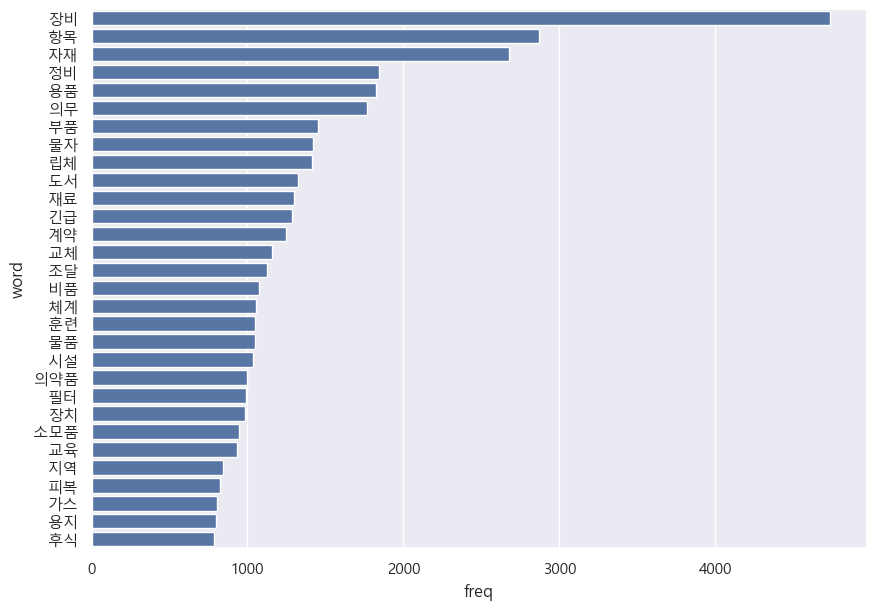

In [23]:
# 그래프 그리기
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'Malgun Gothic'

fig, ax = plt.subplots(figsize=(10, 7))
ax = sns.barplot(y = "word",
                 x = "freq",
                 data = word_count_df[:30])

plt.show()

## 6. Word Cloud

In [27]:
from wordcloud import WordCloud

wc = WordCloud().generate(words_list)
plt.axis('off')
plt.imshow(wc, interpolation = 'bilinear')
plt.show()

TypeError: expected string or bytes-like object, got 'list'

### - 명사로만 입찰명 추출

In [11]:
okt = Okt()

words_N_list = [] #이 리스트에 명사를 담을 예정

for i in range(len(wr_list)):
    text = wr_list[i]
    words = okt.nouns(text)
    words = [word for word in words if len(word) > 1]
    words_N_list.append(words)

words_N_list

[['임시', '명찰', '품목', '구매'],
 ['장거리', '이동', '신병', '도시락', '제조', '납품'],
 ['부대', '중대', '시설', '분전', '제조', '설치'],
 ['학교', '가구', '비품', '제조', '설치'],
 ['부대', '중대', '시설', '조명기구', '제조', '납품'],
 ['난방', '연료'],
 ['부대', '체육', '시설', '비품', '구매', '고소', '작업대'],
 ['액화', '석유', '가스', '구매'],
 ['군수', '취사', '연료'],
 ['갈비', '품목', '덕산', '스포'],
 ['감자전', '품목', '덕산', '스포'],
 ['목적', '작업'],
 ['토양', '정화', '사업', '액화', '석유', '가스', '구매'],
 ['상륙', '기동', '헬기', '초도', '양산', '지원', '장비'],
 ['상반기', '토성', '회관', '자재', '채소', '공산물', '구매'],
 ['어린이집', '교구', '교재', '구매'],
 ['코인', '품목'],
 ['전산', '장비', '유지', '보수', '용역'],
 ['구매', '강원'],
 ['구매', '경기'],
 ['구매', '전라'],
 ['코인', '품목'],
 ['전산', '장비', '유지', '보수', '용역'],
 ['구매', '강원'],
 ['구매', '경기'],
 ['구매', '전라'],
 ['긴급', '영선', '보수', '자재', '구매', '배터리'],
 ['지역', '시설', '공사', '자재', '알루미늄', '패널', '제조', '납품'],
 ['지역', '시설', '공사', '자재', '설치', '납품'],
 ['개편', '부대', '조명등', '제조', '납품', '정정', '공고'],
 ['공병', '여단', '장간', '조립', '자재', '제조', '납품'],
 ['부대', '철책', '시설', '보강', '자재', '구매'],
 ['경축', '세트'],
 ['부대', '복지

In [40]:
word_Ntitle_df = pd.DataFrame(words_N_list)
word_Ntitle_df.to_csv('제목_명사 분리.csv', index=False, encoding='cp949')

In [35]:
flat_words_list = [word for sublist in words_N_list for word in sublist]
word_freq = nltk.FreqDist(flat_words_list)
word = word_freq.keys()
freq = list(word_freq.values())
word_Ncount_df = pd.DataFrame([word , freq],
                      index = ["word","freq"]).T
word_Ncount_df.sort_values(["freq"],
                           ascending= False ,
                           inplace=True)
word_Ncount_df[:100]

,word,freq
3,구매,44030
8,제조,7313
2,품목,6300
14,설치,5167
44,장비,4732
...,...,...
110,생도,372
83,방기,369
314,엔진,369
79,경축,367


In [36]:
import itertools
# words_df = sum(words_list, [])                    # 2중 list를 한 개의 list로 통합
words_df = list(itertools.chain(*words_list))

In [37]:
words_df

['임',
 '시',
 '명',
 '찰',
 '품',
 '목',
 '구',
 '매',
 '장',
 '거',
 '리',
 '이',
 '동',
 '신',
 '병',
 '도',
 '시',
 '락',
 '제',
 '조',
 '납',
 '품',
 '부',
 '대',
 '중',
 '대',
 '시',
 '설',
 '분',
 '전',
 '제',
 '조',
 '설',
 '치',
 '보',
 '다',
 '학',
 '교',
 '가',
 '구',
 '비',
 '품',
 '제',
 '조',
 '설',
 '치',
 '부',
 '대',
 '중',
 '대',
 '시',
 '설',
 '조',
 '명',
 '기',
 '구',
 '제',
 '조',
 '납',
 '품',
 '난',
 '방',
 '연',
 '료',
 '부',
 '대',
 '체',
 '육',
 '시',
 '설',
 '비',
 '품',
 '구',
 '매',
 '고',
 '소',
 '작',
 '업',
 '대',
 '액',
 '화',
 '석',
 '유',
 '가',
 '스',
 '구',
 '매',
 '군',
 '수',
 '취',
 '사',
 '연',
 '료',
 '갈',
 '비',
 '품',
 '목',
 '덕',
 '산',
 '스',
 '포',
 '감',
 '자',
 '전',
 '품',
 '목',
 '덕',
 '산',
 '스',
 '포',
 '목',
 '적',
 '작',
 '업',
 '토',
 '양',
 '정',
 '화',
 '사',
 '업',
 '액',
 '화',
 '석',
 '유',
 '가',
 '스',
 '구',
 '매',
 '상',
 '륙',
 '기',
 '동',
 '헬',
 '기',
 '초',
 '도',
 '양',
 '산',
 '지',
 '원',
 '장',
 '비',
 '상',
 '반',
 '기',
 '토',
 '성',
 '회',
 '관',
 '자',
 '재',
 '채',
 '소',
 '공',
 '산',
 '물',
 '구',
 '매',
 '어',
 '린',
 '이',
 '집',
 '교',
 '구',
 '교',
 '재',
 '구'